# Employee Attrition Prediction: KNN เปรียบเทียบกับ Naive Bayes

Notebook นี้ทดลอง **K-Nearest Neighbors (KNN)** เพื่อเปรียบเทียบกับ Naive Bayes 
โดยใช้ Experimental Setting เดียวกัน และปรับเฉพาะ Hyperparameter ของ KNN เท่านั้น

**Experimental Setting (ค่าคงที่ ใช้เหมือนกันทั้งสองโมเดล)**

| รายการ | ค่าที่ใช้ |
|---|---|
| Train/Test Split | 80:20 (stratify) |
| Feature Set | Top 22 (Top 22 Most Important features ของ Naive Bayes) |
| Class Imbalance | Baseline (ไม่ทำ Resampling) |
| Random State | 42 |
| Cross-Validation | 5-fold Stratified |
| Metric ที่ใช้เลือกโมเดล | Macro F1 |

**KNN Hyperparameters ที่ทดลอง:** `n_neighbors`, `weights`, `metric`

** ผลการทำนายเป็นผลจากการทดลองบนชุดข้อมูลที่ใช้ในการศึกษา ไม่ได้ใช้สำหรับทำนายการลาออกจริงของพนักงาน **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, make_scorer, ConfusionMatrixDisplay, RocCurveDisplay)

## 0. กำหนดค่าคงที่ของการทดลอง

เก็บค่าที่ต้องเหมือนกับ Naive Bayes ไว้ที่เดียว จะได้ไม่ต้องแก้หลายจุด

In [37]:
DATA_FILE = 'C:/Users/Asus/Data Science/Employee-Attrition/data/data_preprocess.csv'   
NB_DIR = 'C:/Users/Asus/Data Science/Employee-Attrition/results/naive_bayes/'          
OUT_DIR = 'C:/Users/Asus/Data Science/Employee-Attrition/results/powerbi/'            
TARGET = 'attrition'            
RANDOM_STATE = 42
TEST_SIZE = 0.20

TOP_22_FEATURES = [
    "days_in_office_required",
    "manager_relationship_score",
    "work_arrangement_onsite",
    "engagement_score",
    "rto_mandate",
    "burnout_score",
    "work_arrangement_remote",
    "work_arrangement_hybrid",
    "salary_vs_market_pct",
    "career_growth_score",
    "tenure_years",
    "ai_tools_adoption",
    "prefers_remote",
    "manager_1on1_per_month",
    "commute_minutes",
    "recent_layoff_round",
    "promotions_last_2y",
    "after_hours_work",
    "age",
    "job_level",
    "salary_usd",
    "weekly_hours"
]

FEATURE_SET_NAME = 'Top 22 Most Important features'   # ชื่อ Feature Set นี้ในไฟล์ผลของ Naive Bayes

CLASS_NAMES = ['No Attrition', 'Attrition']

## 1. อ่านข้อมูลและตรวจสอบเบื้องต้น

อ่านไฟล์ Dataset แล้วดู Shape, ชนิดข้อมูล, Missing values และการกระจายของ Target
เพื่อให้เห็นก่อนว่าข้อมูลมี Class Imbalance แค่ไหน

In [3]:
df = pd.read_csv(DATA_FILE)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.shape)
df.head()

(43439, 38)


,age,job_level,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,department_Engineering,department_Finance,department_HR,department_Marketing,department_Operations,department_Product,department_Sales,work_arrangement_hybrid,work_arrangement_onsite,work_arrangement_remote
0,26,0,1.871802,70000,5.2,0,4,3.806662,1,3,...,0,0,0,1,0,0,0,0,1,0
1,35,0,0.405465,64000,-15.5,0,5,3.891820,1,2,...,0,0,0,0,0,0,1,0,1,0
2,23,2,1.098612,142000,-15.9,1,3,3.583519,1,3,...,0,0,1,0,0,0,0,1,0,0
3,20,4,1.163151,147000,2.6,0,5,2.833213,0,5,...,0,0,0,0,0,0,1,0,1,0
4,40,2,1.945910,141000,11.3,1,4,4.025352,1,4,...,0,0,0,0,0,0,0,1,0,0


In [4]:
print(df.dtypes)

age                              int64
job_level                        int64
tenure_years                   float64
salary_usd                       int64
salary_vs_market_pct           float64
rto_mandate                      int64
days_in_office_required          int64
commute_minutes                float64
prefers_remote                   int64
flexibility_importance           int64
ai_tools_adoption                int64
weekly_hours                     int64
after_hours_work                 int64
burnout_score                  float64
manager_relationship_score       int64
manager_1on1_per_month           int64
engagement_score                 int64
promotions_last_2y               int64
career_growth_score              int64
recent_layoff_round              int64
team_size                        int64
attrition                        int64
salary_vs_level                float64
gender_Female                    int64
gender_Male                      int64
gender_Other             

In [5]:
# Missing values
print(df.isnull().sum())

age                            0
job_level                      0
tenure_years                   0
salary_usd                     0
salary_vs_market_pct           0
rto_mandate                    0
days_in_office_required        0
commute_minutes                0
prefers_remote                 0
flexibility_importance         0
ai_tools_adoption              0
weekly_hours                   0
after_hours_work               0
burnout_score                  0
manager_relationship_score     0
manager_1on1_per_month         0
engagement_score               0
promotions_last_2y             0
career_growth_score            0
recent_layoff_round            0
team_size                      0
attrition                      0
salary_vs_level                0
gender_Female                  0
gender_Male                    0
gender_Other                   0
department_Customer Support    0
department_Data                0
department_Engineering         0
department_Finance             0
department

In [6]:
# Target distribution (จำนวนและสัดส่วนของแต่ละ Class)
class_count = df[TARGET].value_counts().sort_index()
class_ratio = df[TARGET].value_counts(normalize=True).sort_index()

class_table = pd.DataFrame({'class': CLASS_NAMES, 'count': class_count.values, 'ratio': class_ratio.values})
class_table

,class,count,ratio
0,No Attrition,35508,0.817422
1,Attrition,7931,0.182578


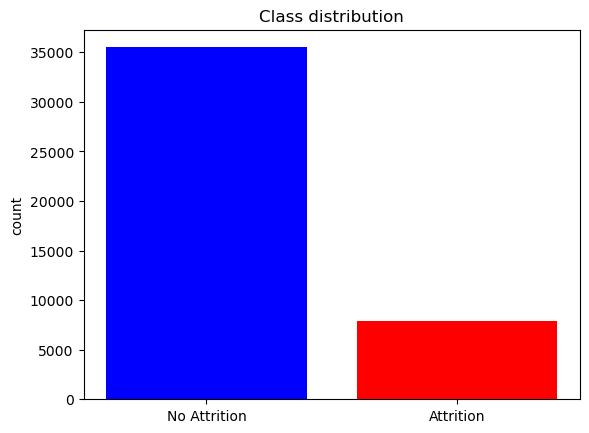

In [7]:
plt.bar(class_table['class'], class_table['count'], color=['b', 'r'])
plt.title('Class distribution')
plt.ylabel('count')
plt.show()

### ตรวจสอบ Feature Columns ที่ใช้

เช็คว่า Top 22 Features มีครบใน Dataset และเป็นตัวเลขทั้งหมด (KNN คำนวณระยะทาง ต้องเป็นตัวเลข)

In [8]:
missing_cols = [c for c in TOP_22_FEATURES if c not in df.columns]
print('Feature ที่ไม่พบใน Dataset:', missing_cols)

print('จำนวน Feature ที่ใช้:', len(TOP_22_FEATURES))
print(df[TOP_22_FEATURES].dtypes.value_counts())

Feature ที่ไม่พบใน Dataset: []
จำนวน Feature ที่ใช้: 22
int64      18
float64     4
Name: count, dtype: int64


## 2. Train/Test Split (80:20)

ใช้ `stratify=y` เพื่อให้สัดส่วน Class ใน Train และ Test เท่ากับข้อมูลเดิม
Test Set จะใช้ตอนประเมินผลสุดท้ายเท่านั้น ไม่ใช้เลือก Hyperparameter

In [9]:
X = df[TOP_22_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('สัดส่วน Attrition ใน Train:', y_train.mean())
print('สัดส่วน Attrition ใน Test :', y_test.mean())

Train: (34751, 22)  Test: (8688, 22)
สัดส่วน Attrition ใน Train: 0.18258467382233604
สัดส่วน Attrition ใน Test : 0.18255064456721914


## 3. Class Imbalance: Baseline

จากการทดลองของ Naive Bayes ที่เปรียบเทียบแนวทางการจัดการ Class Imbalance หลายรูปแบบ พบว่า Baseline ซึ่งไม่มีการจัดการ Class Imbalance เป็น Configuration ที่ให้ผลการทดลองที่เหมาะสมที่สุดภายใต้เงื่อนไขที่กำหนด ดังนั้น ในการทดลอง KNN จึงเลือกใช้ Configuration แบบ Baseline เช่นเดียวกัน เพื่อให้ทั้งสอง Algorithm ใช้เงื่อนไขของข้อมูลที่สอดคล้องกัน และสามารถเปรียบเทียบประสิทธิภาพของแบบจำลองได้อย่างเหมาะสม

ดังนั้น KNN จะใช้ข้อมูล Training ตาม Class Distribution เดิม โดยไม่มีการใช้ Oversampling, Undersampling, SMOTE หรือ Class Weight

## 4. สร้าง Pipeline และ GridSearchCV

KNN ใช้ระยะทางในการตัดสินใจ Feature ที่หน่วยใหญ่ (เช่น `salary_usd`) จะกลบ Feature ที่หน่วยเล็ก
จึงต้องทำ `StandardScaler` ก่อน

ใส่ Scaler ไว้ใน `Pipeline` เพื่อให้ใน Cross-Validation แต่ละ Fold Scaler ถูก fit จาก Train ของ Fold นั้นเท่านั้น
(ไม่เห็นข้อมูล Validation/Test จึงไม่เกิด Data Leakage)

Hyperparameter ที่ทดลอง:
- `n_neighbors`: ใช้ค่าคี่ 3 ถึง 31
- `weights`: uniform, distance
- `metric`: euclidean, manhattan

เลือกจาก **Macro F1** และเก็บ F1 ของ Class Attrition ไว้ด้วย เผื่อใช้ตัดสินกรณีคะแนนใกล้กัน

In [10]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 32, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "macro_f1": "f1_macro",
    "f1_attrition": make_scorer(f1_score, pos_label=1)
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    refit="macro_f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print('GridSearchCV เสร็จแล้ว จำนวน Configuration ที่ทดลอง:', len(grid.cv_results_['params']))

GridSearchCV เสร็จแล้ว จำนวน Configuration ที่ทดลอง: 60


## 5. เก็บผลการทดลอง Hyperparameter

รวมผลจาก `cv_results_` เป็น DataFrame
คอลัมน์ที่เป็นค่าคงที่ของ Experimental Setting ใส่เหมือนกันทุกแถว ส่วน `n_neighbors`, `weights`, `metric`
และ `cv_macro_f1` มาจากผลการรันจริง

In [11]:
res = pd.DataFrame(grid.cv_results_)

knn_results = pd.DataFrame({
    'model': 'KNN',
    'split': '80:20',
    'feature_set': FEATURE_SET_NAME,
    'n_features': len(TOP_22_FEATURES),
    'imbalance_strategy': 'Baseline',
    'n_neighbors': res['param_knn__n_neighbors'].astype(int),
    'weights': res['param_knn__weights'],
    'metric': res['param_knn__metric'],
    'cv_macro_f1': res['mean_test_macro_f1'],
    'cv_f1_attrition': res['mean_test_f1_attrition']
})

knn_results = knn_results.sort_values('cv_macro_f1', ascending=False).reset_index(drop=True)
knn_results.head(10)

,model,split,feature_set,n_features,imbalance_strategy,n_neighbors,weights,metric,cv_macro_f1,cv_f1_attrition
0,KNN,80:20,Top 22 Most Important features,22,Baseline,5,distance,euclidean,0.631498,0.368482
1,KNN,80:20,Top 22 Most Important features,22,Baseline,5,uniform,euclidean,0.631491,0.368428
2,KNN,80:20,Top 22 Most Important features,22,Baseline,7,distance,euclidean,0.631187,0.363467
3,KNN,80:20,Top 22 Most Important features,22,Baseline,7,uniform,euclidean,0.631123,0.363334
4,KNN,80:20,Top 22 Most Important features,22,Baseline,3,uniform,euclidean,0.630405,0.374763
5,KNN,80:20,Top 22 Most Important features,22,Baseline,3,distance,euclidean,0.630351,0.374692
6,KNN,80:20,Top 22 Most Important features,22,Baseline,7,uniform,manhattan,0.629248,0.359113
7,KNN,80:20,Top 22 Most Important features,22,Baseline,7,distance,manhattan,0.628889,0.358534
8,KNN,80:20,Top 22 Most Important features,22,Baseline,9,uniform,euclidean,0.626880,0.352765
9,KNN,80:20,Top 22 Most Important features,22,Baseline,9,distance,euclidean,0.626725,0.352505


### 5.1 ทดลองค่า K (`n_neighbors`)

ดูว่าเมื่อเปลี่ยน K ค่า CV Macro F1 เปลี่ยนไปอย่างไร โดยแยกเส้นตาม `weights` และ `metric`

ใช้ผลจาก GridSearchCV ที่รันไปแล้ว (เป็นผล Cross-Validation บน Train Set ทั้งหมด ไม่ได้ใช้ Test Set)
เลย์เอาต์กราฟเดียวกันวาดซ้ำได้ด้วย Function เดียว

- K น้อย: โมเดลไวต่อ Noise มีโอกาส Overfit
- K มาก: โมเดลเรียบขึ้น แต่ Class Attrition ที่เป็นกลุ่มน้อยอาจถูก Class ใหญ่กลบ
- จุดที่กราฟสูงสุดคือ K ที่สมดุลที่สุดสำหรับ Setting นี้

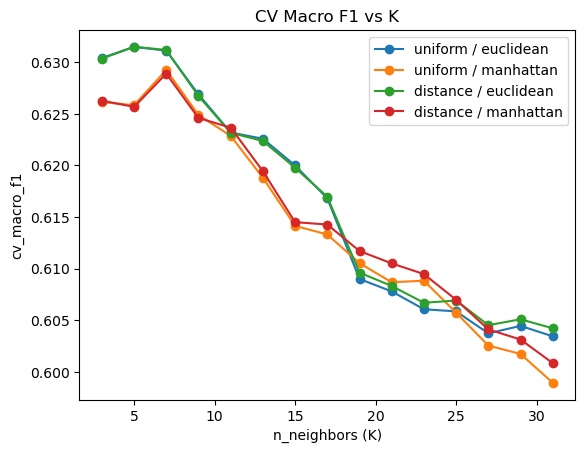

In [12]:
def plot_score_vs_k(score_col, title):
    for w in ['uniform', 'distance']:
        for m in ['euclidean', 'manhattan']:
            part = knn_results[(knn_results['weights'] == w) & (knn_results['metric'] == m)]
            part = part.sort_values('n_neighbors')
            plt.plot(part['n_neighbors'], part[score_col], marker='o', label=w + ' / ' + m)
    plt.xlabel('n_neighbors (K)')
    plt.ylabel(score_col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_score_vs_k('cv_macro_f1', 'CV Macro F1 vs K')

In [13]:
k_table = knn_results.pivot_table(index='n_neighbors', columns=['weights', 'metric'], values='cv_macro_f1')
k_table

weights      distance             uniform          
metric      euclidean manhattan euclidean manhattan
n_neighbors                                        
3            0.630351  0.626282  0.630405  0.626138
5            0.631498  0.625669  0.631491  0.625836
7            0.631187  0.628889  0.631123  0.629248
9            0.626725  0.624591  0.626880  0.624886
11           0.623160  0.623667  0.623189  0.622865
13           0.622368  0.619436  0.622583  0.618797
15           0.619768  0.614495  0.619993  0.614137
17           0.616956  0.614267  0.616806  0.613301
19           0.609601  0.611698  0.608988  0.610524
21           0.608310  0.610497  0.607782  0.608667
23           0.606681  0.609462  0.606053  0.608823
25           0.606899  0.606971  0.605848  0.605716
27           0.604508  0.604097  0.603718  0.602532
29           0.605080  0.603117  0.604440  0.601718
31           0.604203  0.600832  0.603429  0.598925

In [14]:
# K ที่ให้ CV Macro F1 สูงสุดในแต่ละคู่ weights / metric
k_table.idxmax()

weights   metric   
distance  euclidean    5
          manhattan    7
uniform   euclidean    5
          manhattan    7
dtype: int64

**ผลการทดลองค่า K:** เมื่อพิจารณาค่า CV Macro F1 พบว่า `weights=distance` และ `metric=euclidean` ให้ผลสูงสุดที่ K = 5 โดยมีค่า CV Macro F1 เท่ากับ 0.631498 ขณะที่ `weights=distance` และ `metric=manhattan` ให้ผลสูงสุดที่ K = 7 (0.628889) สำหรับ `weights=uniform` และ `metric=euclidean` ให้ผลสูงสุดที่ K = 5 (0.631491) ส่วน `weights=uniform` และ `metric=manhattan` ให้ผลสูงสุดที่ K = 7 (0.629248)

### 5.2 ดูผลต่อ Class Attrition เมื่อเปลี่ยน K

Macro F1 เฉลี่ยสองคลาส จึงดู F1 ของ Class Attrition แยกอีกกราฟ
เพื่อเช็คว่า K ที่ใหญ่ขึ้นทำให้ Class กลุ่มน้อยแย่ลงหรือไม่

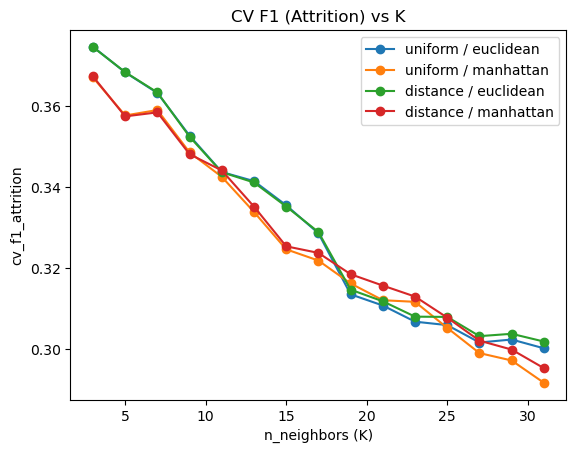

In [15]:
plot_score_vs_k('cv_f1_attrition', 'CV F1 (Attrition) vs K')

**ผลที่สังเกตได้** : จากกราฟพบว่า ค่า CV Macro F1 โดยรวมมีแนวโน้มลดลงเมื่อค่า K เพิ่มขึ้น แม้จะมีความผันผวนเล็กน้อยในบางช่วง โดยการใช้ Euclidean ให้ค่า CV Macro F1 สูงสุดใกล้เคียงกันทั้งสองรูปแบบของ weights และมีค่าสูงสุดในบรรดาคู่พารามิเตอร์ที่ทดลอง

### 5.3 ทดลองการปรับ `weights` (uniform vs distance)

- `uniform`: เพื่อนบ้านทุกตัวมีเสียงเท่ากัน
- `distance`: เพื่อนบ้านที่อยู่ใกล้ได้เสียงมากกว่า

`weights` ของ KNN ไม่ใช่ `class_weight` ไม่ได้ถ่วง Class Imbalance จึงไม่ขัดกับเงื่อนไข Baseline
ตารางนี้เทียบคะแนนที่ดีที่สุดและค่าเฉลี่ยของแต่ละ `weights` (เฉลี่ยข้าม K และ metric)

In [16]:
weights_table = knn_results.groupby('weights')[['cv_macro_f1', 'cv_f1_attrition']].agg(['max', 'mean'])
weights_table

cv_macro_f1           cv_f1_attrition          
                 max      mean             max      mean
weights                                                 
distance    0.631498  0.615709        0.374692  0.329045
uniform     0.631491  0.615161        0.374763  0.327935

In [17]:
# เทียบ distance กับ uniform ที่แต่ละ K (ค่าบวก = distance ดีกว่า)
w_pivot = knn_results.pivot_table(index='n_neighbors', columns=['metric', 'weights'], values='cv_macro_f1')
w_diff = pd.DataFrame({
    'euclidean': w_pivot['euclidean']['distance'] - w_pivot['euclidean']['uniform'],
    'manhattan': w_pivot['manhattan']['distance'] - w_pivot['manhattan']['uniform']
})
w_diff

,euclidean,manhattan
n_neighbors,,
3,-0.000054,0.000144
5,0.000007,-0.000167
7,0.000065,-0.000359
9,-0.000155,-0.000294
11,-0.000030,0.000802
13,-0.000215,0.000639
15,-0.000226,0.000358
17,0.000150,0.000965
19,0.000614,0.001175


**ผลการทดลอง weights:** เมื่อเปรียบเทียบ `weights=distance` กับ `weights=uniform` พบว่า ผลต่างของ CV Macro F1 มีทั้งค่าบวกและค่าลบ โดยค่า Euclidean มีผลต่างค่อนข้างน้อยในช่วง K ต่ำ และมีแนวโน้มเพิ่มขึ้นในช่วง K สูง ส่วน Manhattan มีผลต่างเป็นบวกตั้งแต่ K = 11 เป็นต้นไป และมีแนวโน้มเพิ่มขึ้นเมื่อ K สูงขึ้น โดยมีผลต่างสูงสุดเท่ากับ 0.001908 ที่ K = 31 ทั้งนี้ ผลต่างมีขนาดค่อนข้างเล็ก แสดงว่าการกำหนด weights ทั้งสองรูปแบบให้ผล CV Macro F1 ใกล้เคียงกันโดยรวม

### 5.4 เทียบ `metric` (euclidean vs manhattan)

In [18]:
metric_table = knn_results.groupby('metric')[['cv_macro_f1', 'cv_f1_attrition']].agg(['max', 'mean'])
metric_table

cv_macro_f1           cv_f1_attrition          
                  max      mean             max      mean
metric                                                   
euclidean    0.631498  0.616334        0.374763  0.330295
manhattan    0.629248  0.614536        0.367440  0.326685

**ผลการทดลอง metric:** เมื่อเปรียบเทียบ `euclidean` และ `manhattan` พบว่า `Euclidean` ให้ค่า CV Macro F1 สูงกว่า โดยมีค่า CV Macro F1 สูงสุดเท่ากับ 0.631498 และค่าเฉลี่ยเท่ากับ 0.616334 ขณะที่ `Manhattan` มีค่าสูงสุดเท่ากับ 0.629248 และค่าเฉลี่ยเท่ากับ 0.614536 นอกจากนี้ `Euclidean` ยังให้ค่า CV F1 ของคลาส Attrition สูงกว่า โดยมีค่าสูงสุดและค่าเฉลี่ยเท่ากับ 0.374763 และ 0.330295 ตามลำดับ เมื่อเทียบกับ `manhattan` ที่มีค่า 0.367440 และ 0.326685

## 6. เลือก Best KNN จาก CV Macro F1

เกณฑ์หลักคือ CV Macro F1 สูงสุด (ไม่ดู Test Set)

ถ้ามีหลาย Configuration ที่คะแนนใกล้กัน (ห่างจากค่าสูงสุดไม่เกิน `TOL`) จะใช้เกณฑ์รองตามลำดับ:
1. CV F1 ของ Class Attrition สูงกว่า (เพราะเป็น Class ที่สนใจและเป็น Minority)
2. ถ้ายังเท่ากัน เลือก `n_neighbors` น้อยกว่า (โมเดลเรียบง่ายกว่า)

ตั้ง `TOL = 0.001` เป็นค่าที่เลือกเอง ถ้าตั้งเป็น 0 จะเลือกเฉพาะคะแนนสูงสุดตรง ๆ

In [19]:
TOL = 0.001

top_score = knn_results['cv_macro_f1'].max()
candidates = knn_results[knn_results['cv_macro_f1'] >= top_score - TOL]
print('จำนวน Configuration ที่คะแนนใกล้เคียงสูงสุด:', len(candidates))

candidates = candidates.sort_values(['cv_f1_attrition', 'n_neighbors'], ascending=[False, True])
best_row = candidates.iloc[0]

best_params = {
    'knn__n_neighbors': int(best_row['n_neighbors']),
    'knn__weights': best_row['weights'],
    'knn__metric': best_row['metric']
}

print('Best KNN Configuration')
print('Split:', best_row['split'])
print('Feature Set:', best_row['feature_set'])
print('Number of Features:', best_row['n_features'])
print('Imbalance Strategy:', best_row['imbalance_strategy'])
print('Best K:', best_row['n_neighbors'])
print('Weights:', best_row['weights'])
print('Metric:', best_row['metric'])
print('CV Macro F1:', best_row['cv_macro_f1'])
print('CV F1 (Attrition):', best_row['cv_f1_attrition'])

# ดูว่าตรงกับที่ GridSearchCV เลือกเองหรือไม่
print('GridSearchCV best_params_:', grid.best_params_)

จำนวน Configuration ที่คะแนนใกล้เคียงสูงสุด: 4
Best KNN Configuration
Split: 80:20
Feature Set: Top 22 Most Important features
Number of Features: 22
Imbalance Strategy: Baseline
Best K: 5
Weights: distance
Metric: euclidean
CV Macro F1: 0.631498015811655
CV F1 (Attrition): 0.36848190255256336
GridSearchCV best_params_: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}


## 7. Final Evaluation บน Test Set

เอา Best KNN มา Train ใหม่บน Train Set ทั้งก้อน แล้วประเมินบน Test Set ที่แบ่งไว้ตั้งแต่ต้น
เป็นการใช้ Test Set ครั้งแรกและครั้งเดียว

In [20]:
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=best_params['knn__n_neighbors'],
        weights=best_params['knn__weights'],
        metric=best_params['knn__metric']
    ))
])
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]


def evaluate_model(y_true, y_pred, y_proba):
    return {
        'test_accuracy': accuracy_score(y_true, y_pred),
        'test_precision': precision_score(y_true, y_pred, pos_label=1),
        'test_recall': recall_score(y_true, y_pred, pos_label=1),
        'test_f1': f1_score(y_true, y_pred, pos_label=1),
        'test_macro_f1': f1_score(y_true, y_pred, average='macro'),
        'test_balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'test_roc_auc': roc_auc_score(y_true, y_proba)
    }

knn_test = evaluate_model(y_test, y_pred, y_proba)
pd.DataFrame(knn_test, index=['KNN']).T

,KNN
test_accuracy,0.826312
test_precision,0.542077
test_recall,0.312736
test_f1,0.396641
test_macro_f1,0.647598
test_balanced_accuracy,0.626869
test_roc_auc,0.746953


In [21]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

No Attrition       0.86      0.94      0.90      7102
   Attrition       0.54      0.31      0.40      1586

    accuracy                           0.83      8688
   macro avg       0.70      0.63      0.65      8688
weighted avg       0.80      0.83      0.81      8688



### Confusion Matrix และ ROC Curve ของ Best KNN

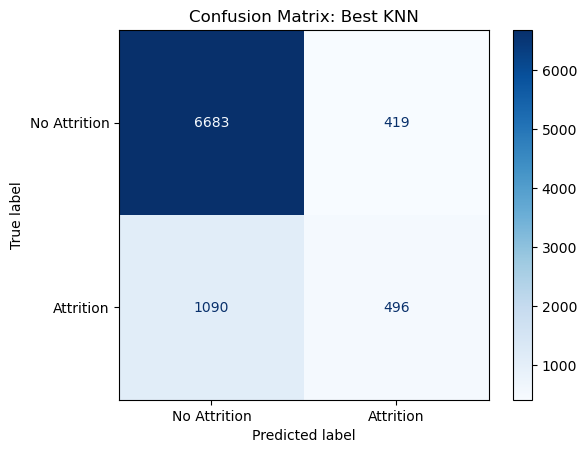

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap='Blues')
plt.title('Confusion Matrix: Best KNN')
plt.show()

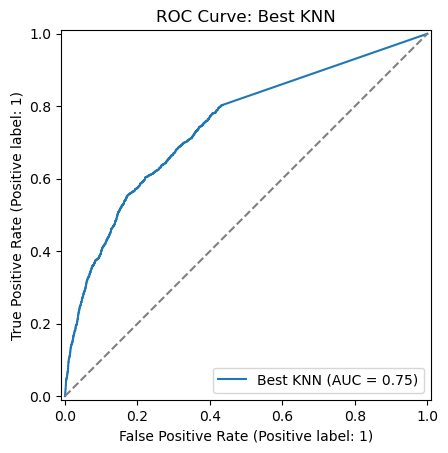

In [23]:
RocCurveDisplay.from_predictions(y_test, y_proba, name='Best KNN')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve: Best KNN')
plt.show()

## 8. อ่านผล Naive Bayes จาก CSV

ห้ามรัน Naive Bayes ใหม่ ใช้ค่าจากไฟล์ที่เพื่อนส่งมาเท่านั้น (ไฟล์ผลรอบล่าสุด 4 ไฟล์)

- `nb_final_metrics.csv`: Test Metrics ของ Best Naive Bayes
- `nb_best_per_split.csv`: CV Macro F1 และ Hyperparameter ของ Best Naive Bayes แต่ละ Split
- `nb_class_metrics.csv`: Precision, Recall, F1, Support รายคลาส
- `nb_confusion_matrix.csv`: Confusion Matrix บน Test Set

ขั้นแรกดูโครงสร้างและชื่อคอลัมน์ของแต่ละไฟล์ก่อน

In [24]:
nb_final = pd.read_csv(NB_DIR + 'nb_final_metrics.csv')
nb_best_split = pd.read_csv(NB_DIR + 'nb_best_per_split.csv')
nb_class_all = pd.read_csv(NB_DIR + 'nb_class_metrics.csv')
nb_cm = pd.read_csv(NB_DIR + 'nb_confusion_matrix.csv')

print(nb_final.columns.tolist())
print(nb_best_split.columns.tolist())
print(nb_class_all.columns.tolist())
print(nb_cm.columns.tolist())
nb_final

['Model', 'Split', 'Feature_Set', 'N_Features', 'Strategy', 'Var_Smoothing', 'Accuracy', 'Precision', 'Recall', 'F1', 'Macro_F1', 'Balanced_Accuracy', 'ROC_AUC']
['Split', 'Feature_Set', 'Strategy', 'N_Features', 'Best_Var_Smoothing', 'CV_Macro_F1_Mean', 'CV_Macro_F1_Std', 'CV_F1_No_Attrition_Mean', 'CV_F1_No_Attrition_Std', 'CV_F1_Attrition_Mean', 'CV_F1_Attrition_Std']
['Class', 'precision', 'recall', 'f1-score', 'support']
['Actual', 'Predicted', 'Count']


,Model,Split,Feature_Set,N_Features,Strategy,Var_Smoothing,Accuracy,Precision,Recall,F1,Macro_F1,Balanced_Accuracy,ROC_AUC
0,Naive Bayes,80:20,Top 22 Most Important features,22,Baseline,0.01,0.819291,0.504896,0.520177,0.512422,0.700758,0.703132,0.809901


In [25]:
nb_best_split

,Split,Feature_Set,Strategy,N_Features,Best_Var_Smoothing,CV_Macro_F1_Mean,CV_Macro_F1_Std,CV_F1_No_Attrition_Mean,CV_F1_No_Attrition_Std,CV_F1_Attrition_Mean,CV_F1_Attrition_Std
0,80:20,Top 22 Most Important features,Baseline,22,0.01,0.692823,0.009112,0.887840,0.004247,0.497806,0.014138
1,70:30,Top 22 Most Important features,Baseline,22,0.10,0.691171,0.005821,0.891696,0.002432,0.490645,0.010592


In [26]:
nb_class_all

,Class,precision,recall,f1-score,support
0,No Attrition,0.892118,0.886088,0.889093,7102.000000
1,Attrition,0.504896,0.520177,0.512422,1586.000000
2,accuracy,0.819291,0.819291,0.819291,0.819291
3,macro avg,0.698507,0.703132,0.700758,8688.000000
4,weighted avg,0.821430,0.819291,0.820332,8688.000000


In [27]:
nb_cm

,Actual,Predicted,Count
0,No Attrition,No Attrition,6293
1,No Attrition,Attrition,809
2,Attrition,No Attrition,761
3,Attrition,Attrition,825


### ตรวจสอบ Best Naive Bayes จาก CSV

Best Naive Bayes ที่ใช้เป็นฐาน คือ 80:20, Top 22, Baseline (`var_smoothing` ให้ดูจากไฟล์)
ขั้นนี้เช็คว่าไฟล์ CSV ตรงกับ Setting นี้ และทุกไฟล์มาจากการรันรอบเดียวกัน
ถ้าไม่ตรง Cell จะหยุดพร้อมข้อความแจ้ง จะได้ไม่เอาผลต่างรอบมาเปรียบเทียบกัน

In [28]:
# แถวของ Best Naive Bayes (80:20, Top 22, Baseline)
nb_f = nb_final[(nb_final['Split'] == '80:20') & (nb_final['Feature_Set'] == FEATURE_SET_NAME)
                & (nb_final['Strategy'] == 'Baseline')]
nb_c = nb_best_split[(nb_best_split['Split'] == '80:20') & (nb_best_split['Feature_Set'] == FEATURE_SET_NAME)
                     & (nb_best_split['Strategy'] == 'Baseline')]

if len(nb_f) == 0 or len(nb_c) == 0:
    raise ValueError('CSV ของ Naive Bayes ไม่มี Setting 80:20 / Top 22 / Baseline - '
                     'น่าจะเป็นไฟล์เก่า ให้ใช้ไฟล์ที่ Export จากการรันรอบล่าสุด')

nb_f = nb_f.iloc[0]
nb_c = nb_c.iloc[0]
nb_class = nb_class_all[nb_class_all['Class'].isin(CLASS_NAMES)]

# เช็คว่าไฟล์มาจากรอบเดียวกัน: Recall ของ Attrition จาก Confusion Matrix ต้องเท่ากับใน nb_class_metrics
tp = nb_cm[(nb_cm['Actual'] == 'Attrition') & (nb_cm['Predicted'] == 'Attrition')]['Count'].sum()
fn = nb_cm[(nb_cm['Actual'] == 'Attrition') & (nb_cm['Predicted'] == 'No Attrition')]['Count'].sum()
cm_recall = tp / (tp + fn)
class_recall = nb_class[nb_class['Class'] == 'Attrition']['recall'].iloc[0]
print('Recall Attrition จาก Confusion Matrix:', cm_recall)
print('Recall Attrition จาก nb_class_metrics:', class_recall)
print('Recall Attrition จาก nb_final_metrics:', nb_f['Recall'])
if abs(cm_recall - class_recall) > 1e-4 or abs(nb_f['Recall'] - class_recall) > 1e-4:
    raise ValueError('ไฟล์ของ Naive Bayes ไม่ตรงกัน (น่าจะมาคนละรอบ) - ให้ใช้ไฟล์ชุดเดียวกันจากการรันครั้งเดียว')

print()
print('Best Naive Bayes จาก CSV')
print('  Split              :', nb_f['Split'])
print('  Feature_Set        :', nb_f['Feature_Set'])
print('  N_Features         :', nb_f['N_Features'], '| KNN ใช้:', len(TOP_22_FEATURES))
print('  Strategy           :', nb_f['Strategy'])
print('  Var_Smoothing      :', nb_f['Var_Smoothing'])
print('  CV Macro F1        :', nb_c['CV_Macro_F1_Mean'])

# Test Set ต้องมีขนาดเท่ากัน
print()
print('Test size ของ NB (รวม support):', nb_class['support'].sum())
print('ผลรวม Confusion Matrix ของ NB :', nb_cm['Count'].sum())
print('Test size ของ KNN             :', len(y_test))

Recall Attrition จาก Confusion Matrix: 0.5201765447667087
Recall Attrition จาก nb_class_metrics: 0.5201765447667087
Recall Attrition จาก nb_final_metrics: 0.5201765447667087

Best Naive Bayes จาก CSV
  Split              : 80:20
  Feature_Set        : Top 22 Most Important features
  N_Features         : 22 | KNN ใช้: 22
  Strategy           : Baseline
  Var_Smoothing      : 0.01
  CV Macro F1        : 0.692823151619897

Test size ของ NB (รวม support): 8688.0
ผลรวม Confusion Matrix ของ NB : 8688
Test size ของ KNN             : 8688


### สร้างตารางผลของ Naive Bayes ในรูปแบบเดียวกับ KNN

ค่า Test Metric ใช้จาก `nb_final_metrics.csv` ส่วน CV Macro F1 ใช้จาก `nb_best_per_split.csv`
Precision, Recall, F1 ในไฟล์นี้เป็นของ Class Attrition

In [29]:
nb_best = pd.DataFrame([{
    'model': 'Naive Bayes',
    'split': nb_f['Split'],
    'feature_set': nb_f['Feature_Set'],
    'n_features': nb_f['N_Features'],
    'imbalance_strategy': nb_f['Strategy'],
    'hyperparameters': 'var_smoothing=' + str(nb_f['Var_Smoothing']),
    'cv_macro_f1': nb_c['CV_Macro_F1_Mean'],
    'test_accuracy': nb_f['Accuracy'],
    'test_precision': nb_f['Precision'],
    'test_recall': nb_f['Recall'],
    'test_f1': nb_f['F1'],
    'test_macro_f1': nb_f['Macro_F1'],
    'test_balanced_accuracy': nb_f['Balanced_Accuracy'],
    'test_roc_auc': nb_f['ROC_AUC']
}])
nb_best.T

,0
model,Naive Bayes
split,80:20
feature_set,Top 22 Most Important features
n_features,22
imbalance_strategy,Baseline
hyperparameters,var_smoothing=0.01
cv_macro_f1,0.692823
test_accuracy,0.819291
test_precision,0.504896
test_recall,0.520177


In [30]:
# ข้อมูล KNN ในรูปแบบเดียวกัน (Best KNN)
knn_best = pd.DataFrame([{
    'model': 'KNN',
    'split': best_row['split'],
    'feature_set': best_row['feature_set'],
    'n_features': best_row['n_features'],
    'imbalance_strategy': best_row['imbalance_strategy'],
    'hyperparameters': ('n_neighbors=' + str(best_row['n_neighbors']) +
                        ', weights=' + best_row['weights'] +
                        ', metric=' + best_row['metric']),
    'cv_macro_f1': best_row['cv_macro_f1'],
    **knn_test
}])
knn_best.T

,0
model,KNN
split,80:20
feature_set,Top 22 Most Important features
n_features,22
imbalance_strategy,Baseline
hyperparameters,"n_neighbors=5, weights=distance, metric=euclidean"
cv_macro_f1,0.631498
test_accuracy,0.826312
test_precision,0.542077
test_recall,0.312736


## Model Comparison: KNN vs Naive Bayes

### 8.1 Comparison of Experimental Methods

ข้อมูลฝั่ง Naive Bayes ดึงจาก CSV ฝั่ง KNN ดึงจากผลการรันจริง

In [31]:
method_table = pd.DataFrame({
    'Aspect': ['Train/Test Split', 'Feature Set', 'Number of Features', 'Imbalance Strategy',
               'Cross-Validation', 'Selection Metric', 'Model Hyperparameters'],
    'Naive Bayes': [nb_best.loc[0, 'split'], nb_best.loc[0, 'feature_set'], nb_best.loc[0, 'n_features'],
                    nb_best.loc[0, 'imbalance_strategy'], '5-fold Stratified', 'Macro F1',
                    nb_best.loc[0, 'hyperparameters']],
    'KNN': [knn_best.loc[0, 'split'], knn_best.loc[0, 'feature_set'], knn_best.loc[0, 'n_features'],
            knn_best.loc[0, 'imbalance_strategy'], '5-fold Stratified', 'Macro F1',
            knn_best.loc[0, 'hyperparameters']]
})
method_table

,Aspect,Naive Bayes,KNN
0,Train/Test Split,80:20,80:20
1,Feature Set,Top 22 Most Important features,Top 22 Most Important features
2,Number of Features,22,22
3,Imbalance Strategy,Baseline,Baseline
4,Cross-Validation,5-fold Stratified,5-fold Stratified
5,Selection Metric,Macro F1,Macro F1
6,Model Hyperparameters,var_smoothing=0.01,"n_neighbors=5, weights=distance, metric=euclidean"


ช่อง Cross-Validation และ Selection Metric ของ Naive Bayes ในตารางเป็นค่าที่ระบุไว้ใน Prompt ของโปรเจกต์
ไม่ได้มาจากไฟล์ CSV (ใน CSV มีเฉพาะ `CV_Macro_F1` ซึ่งยืนยันว่าใช้ Macro F1 แต่ไม่ได้ระบุจำนวน Fold)
ช่องที่เป็น NaN คือข้อมูลที่ CSV ไม่มี

### 9. Performance Comparison

In [32]:
metric_cols = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1',
               'test_macro_f1', 'test_balanced_accuracy', 'test_roc_auc']

perf_table = pd.concat([nb_best, knn_best], ignore_index=True)[['model'] + metric_cols]
perf_table.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Macro F1',
                      'Balanced Accuracy', 'ROC-AUC']
perf_table

,Model,Accuracy,Precision,Recall,F1,Macro F1,Balanced Accuracy,ROC-AUC
0,Naive Bayes,0.819291,0.504896,0.520177,0.512422,0.700758,0.703132,0.809901
1,KNN,0.826312,0.542077,0.312736,0.396641,0.647598,0.626869,0.746953


Precision, Recall, F1 ในตารางนี้เป็นของ Class Attrition

### 10. Class-level Comparison

In [33]:
# KNN: ดึงจาก classification_report
rep = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

knn_class = pd.DataFrame({
    'model': 'KNN',
    'class': CLASS_NAMES,
    'precision': [rep[c]['precision'] for c in CLASS_NAMES],
    'recall': [rep[c]['recall'] for c in CLASS_NAMES],
    'f1': [rep[c]['f1-score'] for c in CLASS_NAMES],
    'support': [rep[c]['support'] for c in CLASS_NAMES]
})

# Naive Bayes: ดึงจาก nb_class_metrics.csv (เฉพาะสองคลาส)
nb_class_out = pd.DataFrame({
    'model': 'Naive Bayes',
    'class': nb_class['Class'].values,
    'precision': nb_class['precision'].values,
    'recall': nb_class['recall'].values,
    'f1': nb_class['f1-score'].values,
    'support': nb_class['support'].values
})

class_metrics = pd.concat([nb_class_out, knn_class], ignore_index=True)
class_metrics

,model,class,precision,recall,f1,support
0,Naive Bayes,No Attrition,0.892118,0.886088,0.889093,7102.0
1,Naive Bayes,Attrition,0.504896,0.520177,0.512422,1586.0
2,KNN,No Attrition,0.859771,0.941003,0.898555,7102.0
3,KNN,Attrition,0.542077,0.312736,0.396641,1586.0


### 11. Interpretation

จากการทดลอง KNN ภายใต้ Experimental Setting เดียวกับ Naive Bayes ได้แก่ 80:20 Train/Test Split, Top 22 Features และ Baseline Class Imbalance พบว่า Configuration ที่ได้ค่า CV Macro F1 สูงสุดคือ `n_neighbors=5`, `weights=distance` และ `metric=euclidean` โดยมีค่า CV Macro F1 เท่ากับ 0.631498

เมื่อนำ Best KNN มาทดสอบบน Test Set พบว่า Accuracy เท่ากับ 0.826312 และ Macro F1 เท่ากับ 0.647598 ขณะที่ Balanced Accuracy และ ROC-AUC เท่ากับ 0.626869 และ 0.746953 ตามลำดับ

เมื่อดูผลราย Class พบว่า KNN สามารถจำแนก No Attrition ได้ด้วย Precision 0.859771, Recall 0.941003 และ F1 0.898555 ส่วน Class Attrition มี Precision 0.542077, Recall 0.312736 และ F1 0.396641

เมื่อเปรียบเทียบกับ Naive Bayes พบว่า KNN มี Accuracy และ Precision สูงกว่าเล็กน้อย แต่มี Macro F1, Balanced Accuracy และ ROC-AUC ต่ำกว่า โดยเฉพาะ Recall และ F1 ของ Class Attrition ที่ KNN มีค่าต่ำกว่า Naive Bayes แสดงให้เห็นว่าผลของทั้งสองโมเดลแตกต่างกันในแต่ละ Metric และควรพิจารณาผลราย Class ร่วมกับค่า Accuracy ก่อนสรุปผลการทดลอง

## 12. Export CSV สำหรับ Power BI

In [34]:
OUT = OUT_DIR

knn_export = knn_results.copy()
knn_export['is_best'] = (
    (knn_export['n_neighbors'] == best_row['n_neighbors']) &
    (knn_export['weights'] == best_row['weights']) &
    (knn_export['metric'] == best_row['metric'])
)
for col in metric_cols:
    knn_export[col] = np.nan
    knn_export.loc[knn_export['is_best'], col] = knn_test[col]

knn_export.to_csv(OUT + 'knn_experiment_results.csv', index=False)

knn_all = knn_export.copy()
knn_all['hyperparameters'] = ('n_neighbors=' + knn_all['n_neighbors'].astype(str) +
                              ', weights=' + knn_all['weights'] +
                              ', metric=' + knn_all['metric'])
common_cols = ['model', 'split', 'feature_set', 'n_features', 'imbalance_strategy',
               'hyperparameters', 'cv_macro_f1'] + metric_cols

model_comparison = pd.concat([nb_best[common_cols], knn_all[common_cols]], ignore_index=True)
model_comparison.to_csv(OUT + 'model_comparison_results.csv', index=False)

best_comparison = pd.concat([nb_best[common_cols], knn_best[common_cols]], ignore_index=True)
best_comparison.to_csv(OUT + 'best_model_comparison.csv', index=False)

class_metrics.to_csv(OUT + 'model_class_metrics.csv', index=False)

cm_rows = []
for i, actual in enumerate(CLASS_NAMES):
    for j, pred in enumerate(CLASS_NAMES):
        cm_rows.append({'model': 'KNN', 'actual_class': actual,
                        'predicted_class': pred, 'count': cm[i, j]})


for _, r in nb_cm.iterrows():
    cm_rows.append({'model': 'Naive Bayes', 'actual_class': r['Actual'],
                    'predicted_class': r['Predicted'], 'count': r['Count']})

pd.DataFrame(cm_rows).to_csv(OUT + 'model_confusion_matrix.csv', index=False)

# --- 26. model_metrics_long.csv ---
metric_names = {'test_accuracy': 'Accuracy', 'test_precision': 'Precision', 'test_recall': 'Recall',
                'test_f1': 'F1 (Attrition)', 'test_macro_f1': 'Macro F1',
                'test_balanced_accuracy': 'Balanced Accuracy', 'test_roc_auc': 'ROC-AUC'}

metrics_long = best_comparison[['model', 'split', 'feature_set', 'imbalance_strategy'] + metric_cols]
metrics_long = metrics_long.melt(id_vars=['model', 'split', 'feature_set', 'imbalance_strategy'],
                                 var_name='metric', value_name='value')
metrics_long['metric'] = metrics_long['metric'].map(metric_names)
metrics_long.to_csv(OUT + 'model_metrics_long.csv', index=False)

print('บันทึกไฟล์เรียบร้อย')

บันทึกไฟล์เรียบร้อย


## 13. ตรวจสอบไฟล์ CSV หลัง Export

อ่านไฟล์กลับมาด้วย `pd.read_csv` ดู `.head()`, `.shape`, `.dtypes` เพื่อเช็คว่าเอาไปใช้ใน Power BI ต่อได้3

In [35]:
csv_files = ['knn_experiment_results.csv', 'model_comparison_results.csv', 'best_model_comparison.csv',
             'model_class_metrics.csv', 'model_confusion_matrix.csv', 'model_metrics_long.csv']

for f in csv_files:
    check = pd.read_csv(OUT + f)
    print('=====', f)
    print('shape:', check.shape)
    print(check.dtypes)
    print(check.head())
    print()

print('ไฟล์ที่บันทึกสำเร็จ:')
for f in csv_files:
    print(' -', OUT + f)

===== knn_experiment_results.csv
shape: (60, 18)
model                      object
split                      object
feature_set                object
n_features                  int64
imbalance_strategy         object
n_neighbors                 int64
weights                    object
metric                     object
cv_macro_f1               float64
cv_f1_attrition           float64
is_best                      bool
test_accuracy             float64
test_precision            float64
test_recall               float64
test_f1                   float64
test_macro_f1             float64
test_balanced_accuracy    float64
test_roc_auc              float64
dtype: object
  model  split                     feature_set  n_features imbalance_strategy  \
0   KNN  80:20  Top 22 Most Important features          22           Baseline   
1   KNN  80:20  Top 22 Most Important features          22           Baseline   
2   KNN  80:20  Top 22 Most Important features          22           Baseline   
3

## Final Summary

จากการทดลอง KNN โดยใช้ Experimental Setting เดียวกับ Naive Bayes พบว่า Configuration ที่เลือกคือ `K=5`, `weights=distance` และ `metric=euclidean` โดยมี CV Macro F1 เท่ากับ 0.631498

บน Test Set KNN ได้ Accuracy 0.826312, Macro F1 0.647598, Balanced Accuracy 0.626869 และ ROC-AUC 0.746953

สำหรับ Class Attrition KNN มี Precision 0.542077, Recall 0.312736 และ F1 0.396641 ส่วน Naive Bayes มี Precision 0.504896, Recall 0.520177 และ F1 0.512422

โดยรวมผลการทดลองแสดงให้เห็นว่า แม้ KNN จะมี Accuracy สูงกว่าเล็กน้อย แต่ผลของ Macro F1, Balanced Accuracy, ROC-AUC และการจำแนก Class Attrition แตกต่างจาก Naive Bayes จึงควรพิจารณาหลาย Metric ร่วมกันในการเปรียบเทียบโมเดล

In [36]:
print('Best KNN:', best_params)
print('CV Macro F1:', best_row['cv_macro_f1'])
print()
print(perf_table.to_string(index=False))
print()
print(class_metrics.to_string(index=False))

Best KNN: {'knn__n_neighbors': 5, 'knn__weights': 'distance', 'knn__metric': 'euclidean'}
CV Macro F1: 0.631498015811655

      Model  Accuracy  Precision   Recall       F1  Macro F1  Balanced Accuracy  ROC-AUC
Naive Bayes  0.819291   0.504896 0.520177 0.512422  0.700758           0.703132 0.809901
        KNN  0.826312   0.542077 0.312736 0.396641  0.647598           0.626869 0.746953

      model        class  precision   recall       f1  support
Naive Bayes No Attrition   0.892118 0.886088 0.889093   7102.0
Naive Bayes    Attrition   0.504896 0.520177 0.512422   1586.0
        KNN No Attrition   0.859771 0.941003 0.898555   7102.0
        KNN    Attrition   0.542077 0.312736 0.396641   1586.0
